# Dependencies


In [224]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import googlemaps
from ares import logger
import os
from pathlib import Path
from dotenv import load_dotenv
from ares.utils.common import load_json, save_json
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["figure.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 0.5

sns.set()
rc = {
    "font.family": ["serif"],
    "font.serif": "Times New Roman",
    "grid.color": "gainsboro",
    "grid.linestyle": "-",
}
sns.set_style(rc=rc)
sns.set_context("notebook", font_scale=0.8)


df = pd.read_csv("../artifacts/data/01-raw/untouched_raw_original.csv")
train_df = pd.read_csv("../artifacts/data/01-raw/train_df.csv")
eval_df = pd.read_csv("../artifacts/data/01-raw/eval_df.csv")
geocode_path = Path("../artifacts/data/04-geocode_cache/geocode_cache.json")
maps = googlemaps.Client(key=os.getenv("GOOGLE_MAPS_KEY"))

load_dotenv()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

[2026-01-01 13:31:22,311: INFO: client: API queries_quota: 60]


In [225]:
print(train_df.shape)
print(eval_df.shape)

(12017, 31)
(3005, 31)


# Geocode localities


In [226]:
df["loc"].value_counts()

loc
East Legon                         1707
Teshie                             1231
Spintex                            1152
Adenta                              849
Accra Metropolitan                  847
Tema Metropolitan                   796
Ashaley Botwe                       583
Airport Residential Area            566
Adjiriganor                         538
Weija                               512
Oyarifa                             492
Ga West Municipal                   418
Achimota                            415
Cantonments                         389
Dome Market                         357
Kasoa                               343
Haatso                              230
Dzorwulu                            208
Ablekuma                            206
West Legon                          201
Dansoman                            199
Pokuase                             198
Ga East Municipal                   157
Oyibi                               136
Ashomang Estate                     

In [227]:
def geocode(x):
    """Geocode a location x using Google Maps API"""
    try:
        result = maps.geocode(x.lower(), region="gh")
        if result:
            lat = result[0]["geometry"]["location"]["lat"]
            lng = result[0]["geometry"]["location"]["lng"]
            return (lat, lng)
    except Exception as e:
        logger.info(f"Error geocoding {x}: {e}")
    return (None, None)


def create_cache(df):
    cache = {}
    locs = df["loc"].unique()
    for i, loc in enumerate(locs, 1):
        lat, lng = geocode(loc)
        cache[loc] = {"lat": lat, "lng": lng}

    save_json(geocode_path, cache)
    return cache


try:
    geocodes_cache = load_json(geocode_path)
except FileNotFoundError:
    geocode_path.parent.mkdir(parents=True, exist_ok=True)
    geocodes_cache = create_cache(df)


def get_lat_lng(location):
    """Fetch the latitude and longitude of a location"""
    location_lower = location.lower()
    if location_lower in geocodes_cache:
        result = geocodes_cache[location_lower]
        return (result["lat"], result["lng"])
    else:
        lat, lng = geocode(location_lower)
        geocodes_cache[location_lower] = {"lat": lat, "lng": lng}
        save_json(geocode_path, geocodes_cache)
        return (lat, lng)


[2026-01-01 13:31:22,399: INFO: common: JSON file loaded successfully from: ../artifacts/data/04-geocode_cache/geocode_cache.json]


In [228]:
# Applying to both train and eval set
train_df[["lat", "lng"]] = train_df["loc"].apply(lambda x: pd.Series(get_lat_lng(x)))
eval_df[["lat", "lng"]] = eval_df["loc"].apply(lambda x: pd.Series(get_lat_lng(x)))

In [229]:
missing_train = train_df[train_df["lat"].isnull()]["loc"].unique()
missing_eval = eval_df[eval_df["lat"].isnull()]["loc"].unique()

logger.warning(
    f"Train data still missing {len(missing_train)} lat/lng for: {missing_train}"
)
logger.warning(
    f"Eval data still missing {len(missing_eval)} lat/lng for: {missing_eval}"
)


[2026-01-01 13:31:24,285: WARNING: 2347945726: Train data still missing 0 lat/lng for: []]
[2026-01-01 13:31:24,287: WARNING: 2347945726: Eval data still missing 0 lat/lng for: []]


# Handling Duplicates


In [230]:
train_df = train_df.drop_duplicates(subset="url")
eval_df = eval_df.drop_duplicates(subset="url")

# Handling Price Outliers


In [231]:
train_df["price"].describe()

count    1.201700e+04
mean     2.090726e+05
std      1.546884e+07
min      1.750000e+02
25%      2.300000e+03
50%      5.000000e+03
75%      1.300000e+04
max      1.655500e+09
Name: price, dtype: float64

In [232]:
x = np.log(train_df["price"])
q1, q3 = np.percentile(x, [25, 75])
iqr = q3 - q1
l1 = q1 - 1.5 * iqr
l2 = q3 + 1.5 * iqr

print(f"Lower bound (log): {l1:.4f}")
print(f"Upper bound (log): {l2:.4f}")
print(f"Lower bound (original): {np.exp(l1):.2f}")
print(f"Upper bound (original): {np.exp(l2):.2f}")

Lower bound (log): 5.1426
Upper bound (log): 12.0708
Lower bound (original): 171.16
Upper bound (original): 174689.43


In [233]:
def plot_price(df, cutoff=100_000, l1=l1, l2=l2):
    plt.figure(num=1, figsize=(20, 10), linewidth=1)

    plt.subplot2grid((2, 3), (0, 0))
    sns.lineplot(
        [df["price"].quantile(p / 100) for p in range(0, 101, 5)], markers=True
    )

    plt.subplot2grid((2, 3), (0, 1))
    sns.distplot(np.log(df["price"]))
    plt.axvline(x=l1, color="b", linestyle=":")
    plt.axvline(x=l2, color="b", linestyle=":")
    plt.xlabel("log(price)")

    ax = plt.subplot2grid((2, 3), (0, 2))
    sm.qqplot(np.log1p(df["price"]), stats.norm, fit=True, line="45", ax=ax)

    plt.subplot2grid((2, 3), (1, 0), colspan=3)
    red = dict(markerfacecolor="r", markeredgecolor="r", marker=".")
    df.price.plot(kind="box", xlim=(0, cutoff), vert=False, flierprops=red)

    plt.tight_layout()


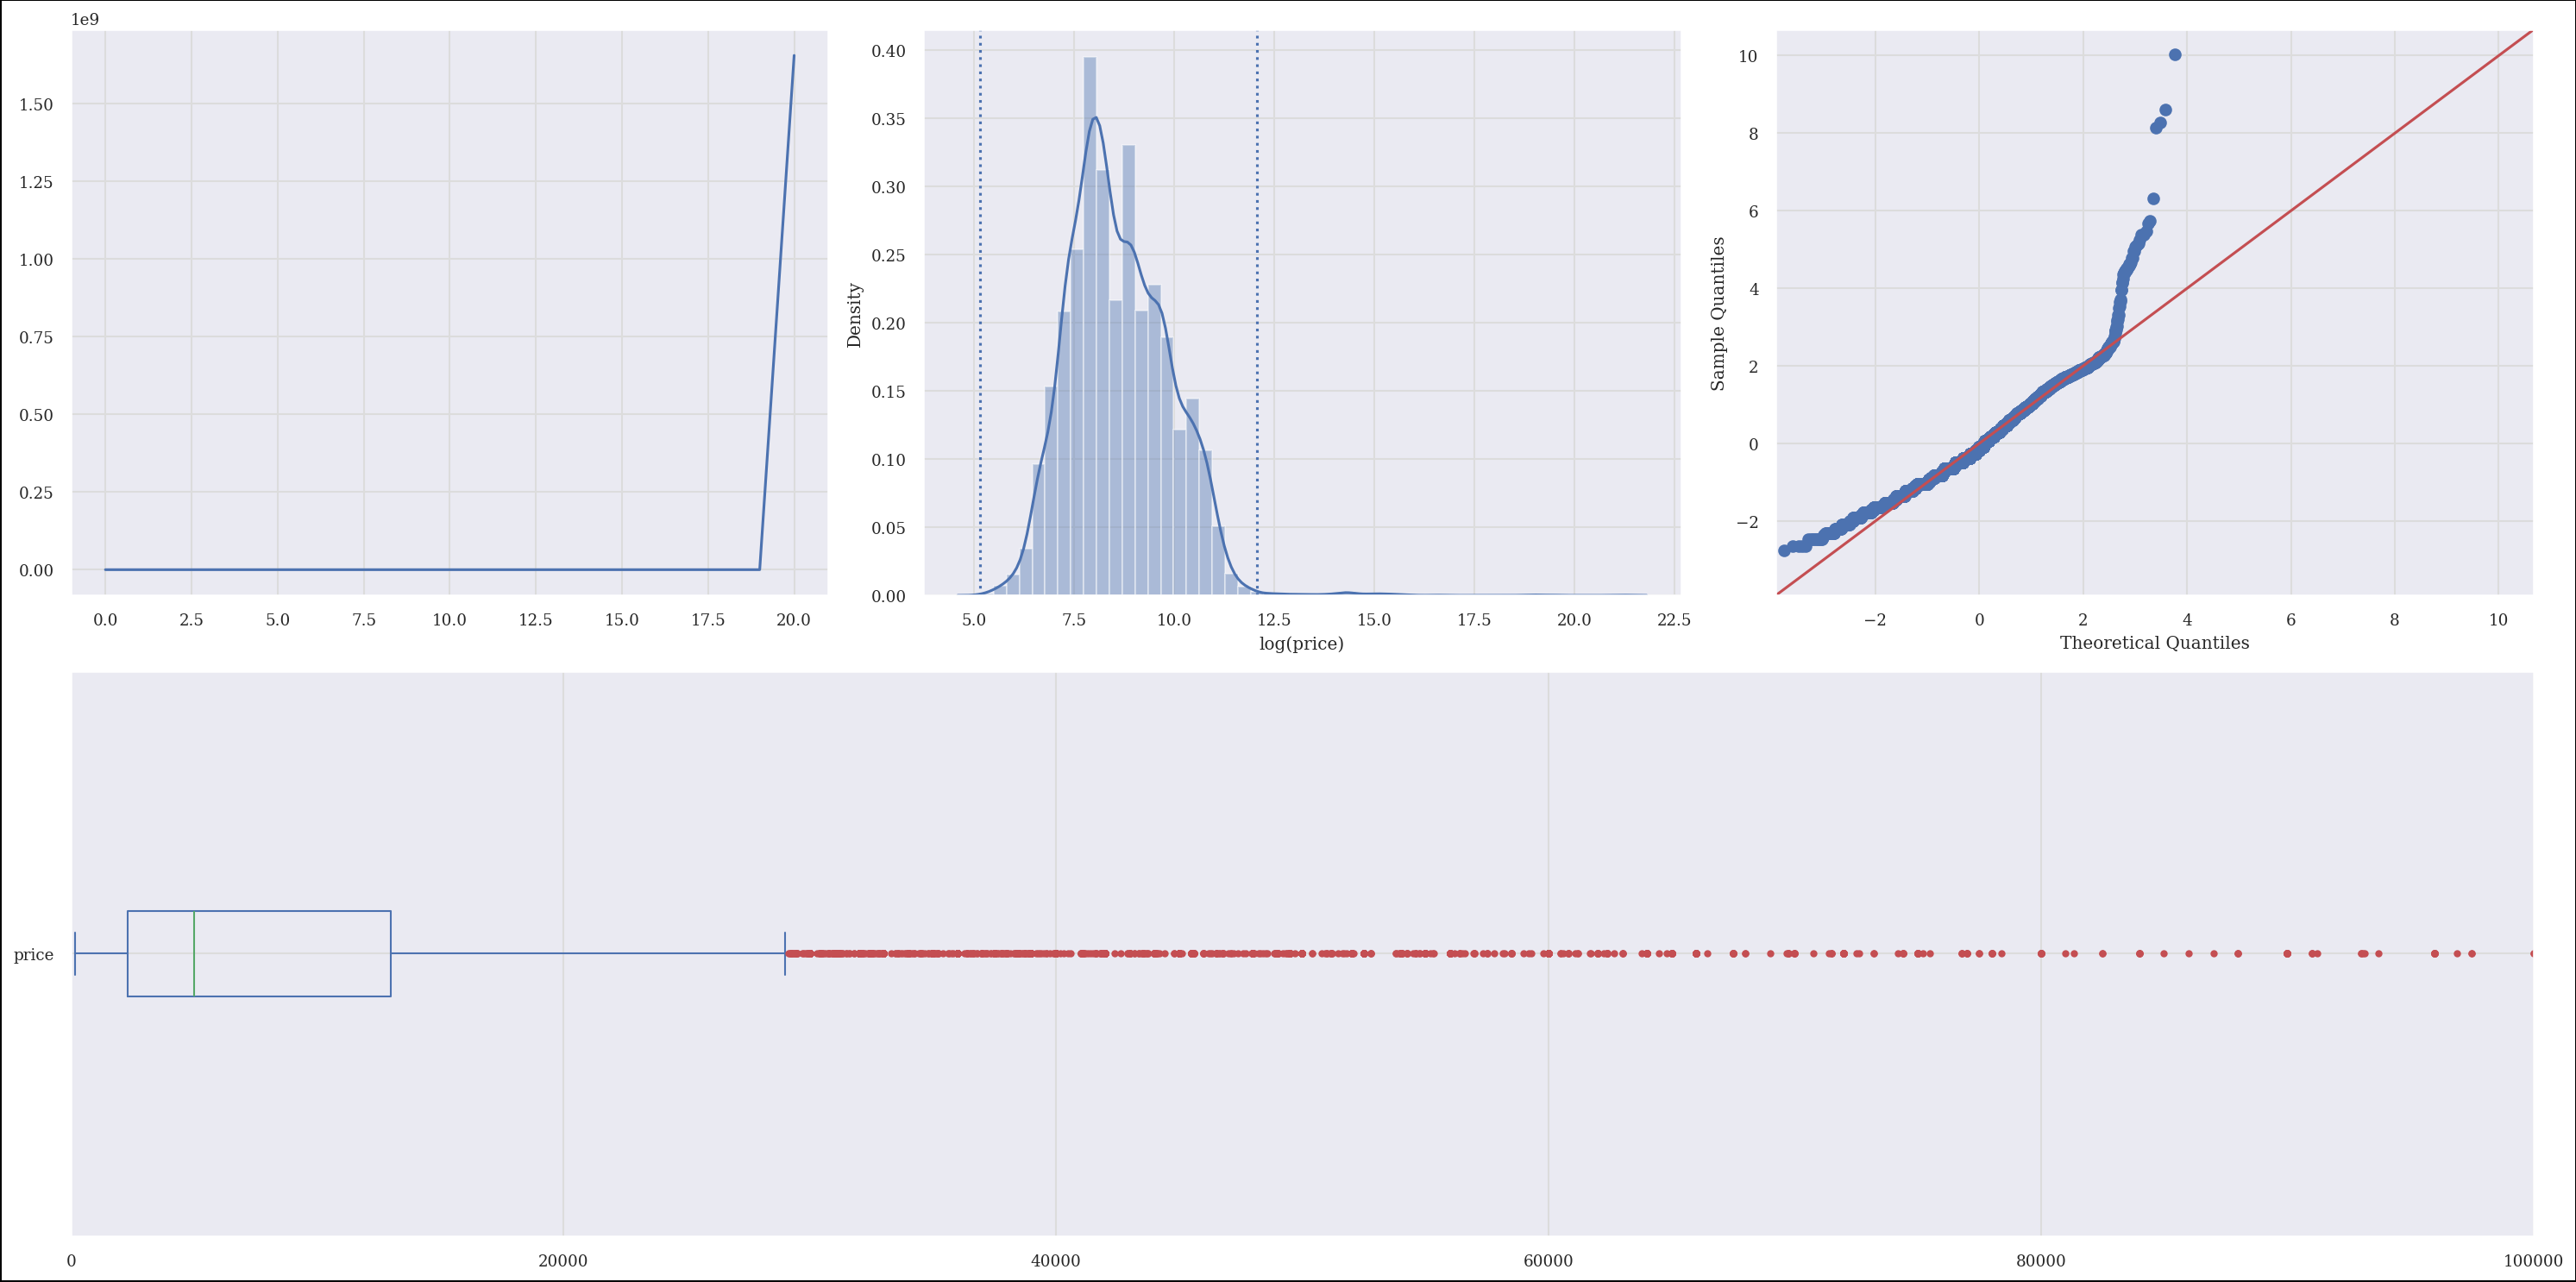

In [234]:
plot_price(train_df)

In [235]:
train_outliers = train_df[
    (np.log(train_df["price"]) < l1) | (np.log(train_df["price"]) > l2)
]

eval_outliers = eval_df[
    (np.log(eval_df["price"]) < l1) | (np.log(eval_df["price"]) > l2)
]

logger.info(
    f"{len(train_outliers)} outliers in training set and {len(eval_outliers)} outliers in evaluation set."
)

[2026-01-01 13:31:25,484: INFO: 816585731: 55 outliers in training set and 7 outliers in evaluation set.]


In [236]:
train_df = train_df.drop(index=train_outliers.index)
eval_df = eval_df.drop(index=eval_outliers.index)

Text(0.5, 1.0, 'Price distribution of training set')

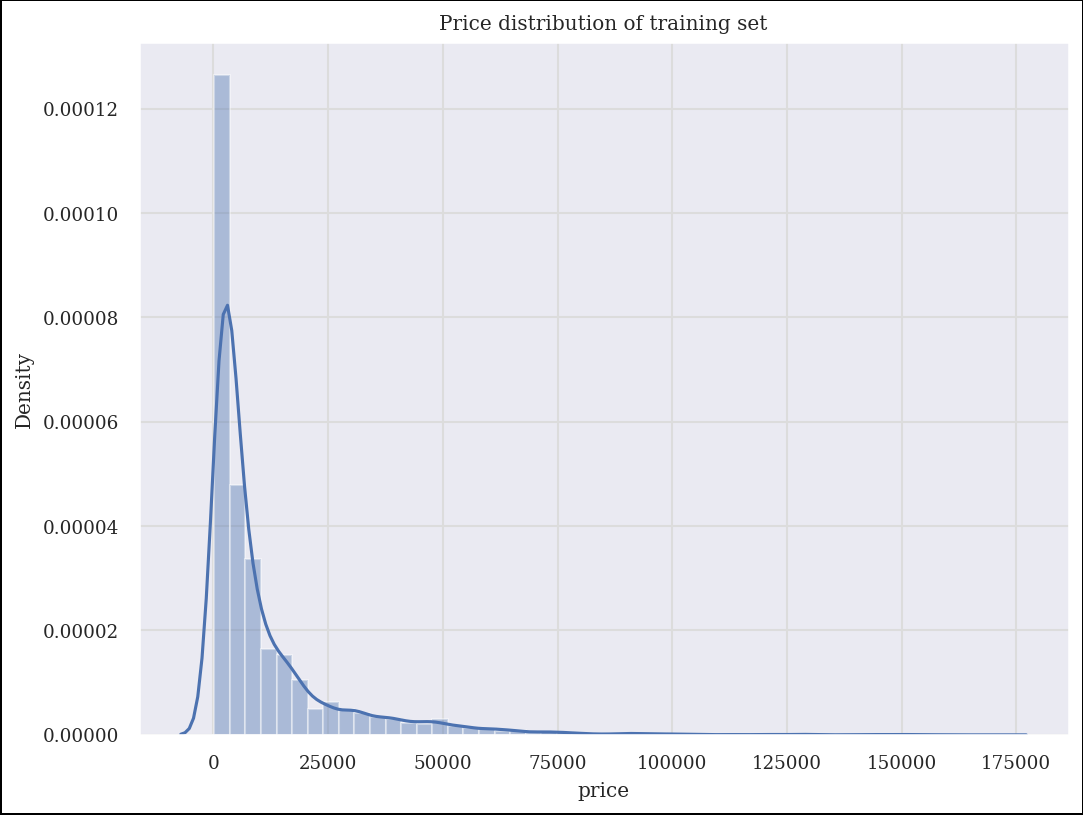

In [237]:
plt.figure(figsize=(8, 6), linewidth=1)
sns.distplot(train_df.price)
plt.title("Price distribution of training set")

# Extra Cleaning


In [238]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11962 entries, 0 to 12016
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           11962 non-null  int64  
 1   url                  11962 non-null  object 
 2   fetch_date           11962 non-null  object 
 3   house_type           11962 non-null  object 
 4   bathrooms            11962 non-null  int64  
 5   bedrooms             11962 non-null  int64  
 6   price                11962 non-null  float64
 7   locality             11962 non-null  object 
 8   Condition            11928 non-null  object 
 9   Furnishing           11962 non-null  object 
 10  Property Size        11914 non-null  float64
 11  24-hour Electricity  11962 non-null  int64  
 12  Air Conditioning     11962 non-null  int64  
 13  Apartment            11962 non-null  int64  
 14  Balcony              11962 non-null  int64  
 15  Chandelier           11962 non-null  int6

In [239]:
train_df.Condition.value_counts()

Condition
Newly-Built    5881
Fairly Used    5446
Renovated       541
Old              60
Name: count, dtype: int64

In [240]:
train_df.Condition = train_df.Condition.map(
    {
        "Newly-Built": "New",
        "Fairly Used": "Used",
        "Old": "Used",
        "Renovated": "Renovated",
    }
)
eval_df.Condition = eval_df.Condition.map(
    {
        "Newly-Built": "New",
        "Fairly Used": "Used",
        "Old": "Used",
        "Renovated": "Renovated",
    }
)

In [241]:
feature_columns = [
    "url",
    "house_type",
    "bathrooms",
    "bedrooms",
    "price",
    "locality",
    "lat",
    "lng",
    "Condition",
    "Furnishing",
    "24-hour Electricity",
    "Air Conditioning",
    "Apartment",
    "Balcony",
    "Chandelier",
    "Dining Area",
    "Dishwasher",
    "Hot Water",
    "Kitchen Cabinets",
    "Kitchen Shelf",
    "Microwave",
    "Pop Ceiling",
    "Pre-Paid Meter",
    "Refrigerator",
    "TV",
    "Tiled Floor",
    "Wardrobe",
    "Wi-Fi",
]

In [242]:
train_df = train_df[feature_columns]
eval_df = eval_df[feature_columns]

train_df = train_df.dropna(subset=feature_columns)
eval_df = eval_df.dropna(subset=feature_columns)

In [243]:
def rename_cols(df):
    for col in df.columns.to_list():
        df.rename(
            columns={col: col.lower().replace(" ", "_").replace("-", "_")}, inplace=True
        )
    return df

In [244]:
train_df = rename_cols(train_df)
eval_df = rename_cols(eval_df)

In [ ]:
train_df.to_csv("../artifacts/data/02-preprocessed/train_df.csv")
eval_df.to_csv("../artifacts/data/02-preprocessed/eval_df.csv")

logger.info(
    f"✅ Cleaning complete, final train size: {train_df.shape}, eval size: {eval_df.shape}"
)

[2026-01-01 13:31:26,396: INFO: 2523435989: ✅ Cleaning complete, final train size: (11928, 28), eval size: (2992, 28)]
